# Chapter 3 | Classification: MNIST handwritten digits recognition

## Data

sklearn.datasets package contains mostly 3 types of functions:
- fetch_* to download real-life datasets;
- load_* to load small toy datasets;
- make_* to generate fake datasets.

Last ones are usually returned as an (X, y) tuple, in which X and y are both NumPy arrays, while the first two return sklearn.utils.Bunch objects, which are dictionaries that generally contains:
- 'DESCR' - description;
- 'data' - the input data, usually as 2D NumPy array;
- 'target' - the labels, usually as 1D NumPy array.

We will use the fetch_openml() function, which is a bit unusual since it returns input as Pandas DataFrame and labels as Pandas Series, but since we're working with images, DataFrames are not ideal, so we will set as_frame = False to get a NumPy array:

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame = False)

In [6]:
X, y = mnist.data, mnist.target
X, y

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

In [6]:
X.shape, y.shape

((70000, 784), (70000,))

We got 70k images, each with 784 features (these are the 28x28 pixels, so each feature is the pixel's intensity from 0 white to 255 black). 

Let's define a function which plots the image:
- reshape the 256 features in a 28x28 array;
- show the image with plt.imshow (cmap = 'binary' get a grayscale colormap)

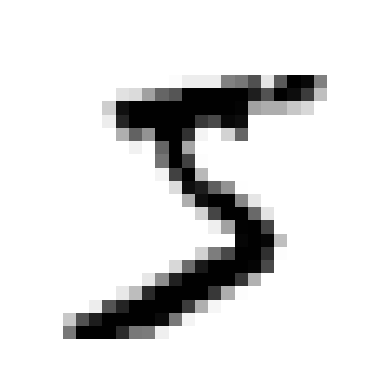

In [8]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap = 'binary')
    plt.axis('off') #remove axis
    plt.show()
    
plot_digit(X[0])

This looks like a 5; let's check the label:

In [9]:
y[0]

'5'

## Train-Test Split
The MNIST dataset is already split into training set (first 60k images) and test set (last 10k images), so we don't need to perform a random split:

In [10]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Binary Classifier
It is the easiest classifier, which needs to solve the task of distinguishing between just 2 classes. In our case, let's focus on building a Binary Classifier which identify just one digit, for example the number 5: the 2 classes are 5 and non-5.

Let's create the target vectors for this classification task:

In [11]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

We will start by training a Stochastic Gradient Descent (SGD), which is a classifier capable of handling very large datasets efficiently:

In [12]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

Let's use it to predict the first observation, which was a 5:

In [14]:
sgd_clf.predict([X[0]])

array([ True])

It guessed right! Let's evaluate this model's performance:

### Performance Measures
Evaluating a classifier is often significantly trickier than evaluating a regressor because there are many performance measures available.

#### Accuracy
As we did for regression, we can use Cross-Validation and this time we would get different Accuracy scores (i.e., ratio of correct predictions); this time the function to use is cross_val_score:

In [16]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring = 'accuracy')

array([0.95035, 0.96035, 0.9604 ])

We got above 95% accuracy! Should we be amazed? Before getting to excited, let's look at a dummy classifier which classifies every single image in the most frequent class (in this case the negative class non-5):

In [17]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
cross_val_score(dummy_clf, X_train, y_train_5, cv = 3, scoring = 'accuracy')

array([0.90965, 0.90965, 0.90965])

We got over 90% accuracy: this is simply because only around 10% of images are 5s, so even a dummy classifier would seem to perform well.

This is proof that accuracy is not the preferred performance measure for classifiers, especially with skewed/unbalanced datasets.

What we should look at instead is the Confusion Matrix (CM):

#### Confusion Matrix
The general idea is to count the number of times instances of class A are classified as class B, for each A/B pair.

Let's first compute the prediction, using the cross_val_predict() function:

In [18]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

We can then easily compute the Confusion Matrix with the confusion_matrix function:

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In a confusion matrix:
- each ROW represents an Actual Class;
- each COLUMN represents a Predicted Class.

The confusion matrix is in the form:

$$
\begin{bmatrix}
    TN & FP \\
    FN & TP
\end{bmatrix}
$$

where: 
- TN = True Negatives: correctly predicted Negatives.
- FP = False Positives: incorrectly predicted Positives (or Type I error).
- FN = False Negatives: incorrectly predicted Negatives (or Type II error).
- TP = True Positives: correctly predicted Positives.

A perfect classifier would only have values on the main diagonal (top left to bottom right).

From the Confusion Matrix we can compute a lot of other metrics:

##### Precision and Recall

- precision = $\frac{TP}{TP+FP}$ -> is the accuracy of the positive predictions (how many of the ones we predicted as positives are real positives); (generally used among the recall);

- recall = sensitivity = TPR = $\frac{TP}{TP+FN}$ -> is the true positive rate (how many positive we predicted correctly over all the positives); (generally used among the precision);

In [20]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred), recall_score(y_train_5, y_train_pred)

(0.8370879772350012, 0.6511713705958311)

We interpret these as:
- precision of 83.7% -> when our classifier predict an image as 5, it is correct 83.7% of times;
- recall of 65.1% -> our classifier detects the 65.1% of 5s.

It is convenient to combine precision and recall into a single metric, called $F_1 score$, which is the harmonic mean of both:
$$ F_1 = 2* \frac{Precision*Recall}{Precision + Recall}$$

In [21]:
from sklearn.metrics import f1_score

f1_score(y_train_5, y_train_pred)

0.7325171197343847

(NOTE: $F_1$ score tends to prefer classifiers having similar precision and recall, but sometimes this is not what we want: in some contexts we could care more about precision, while in other about recall:
- video for kid detector -> it is better if it rejects many good videos (low recall) rather than not rejecting many bad ones (high precision);
- detecting shop thefts from cameras -> it is better if it spots some false thefts (high recall) rather than not spotting some real thefts (low precision)).

Unfortunately, we can't increase both: this is known as Precision/Recall Trade-off: algorithms will use a threshold to assign instances to positive or negative class; we can't change these treshold directly in sklearn, but we can access the Decision Scores assigned by the algorithm (the ones that will then be compared to the treshold to assign a class) and manually compare them to a custom threshold.

We know that SGDClassifier uses a threshold of 0, so doing the sequent code returns the same as using predict():

In [22]:
y_scores = sgd_clf.decision_function([X[0]])
y_scores

array([2164.22030239])

In [25]:
threshold = 0
y_x0_pred = (y_scores > threshold)
y_x0_pred

array([ True])

Let's try to change the threshold:

In [26]:
threshold = 3000
y_x0_pred = (y_scores > threshold)
y_x0_pred

array([False])

This proofs that increasing the threshold will decrease the recall (cause the 5 is no more recognised). So, how do we choose the threshold?

First we use cross_val_predict, but this time we don't want the predictions, but the decision scores:

In [27]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method = 'decision_function')

Then, we use the precision_recall_curve() method to compute precision and recall for all possible thresholds:

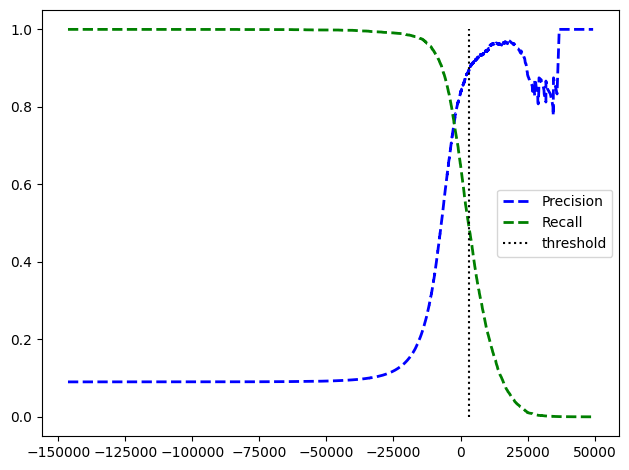

In [32]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], 'b--', label = 'Precision', linewidth = 2)
plt.plot(thresholds, recalls[:-1], 'g--', label = 'Recall', linewidth = 2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label = 'threshold')
plt.legend()
plt.tight_layout()
plt.show()

Another way of selecting the threshold is by plotting precision against recall:

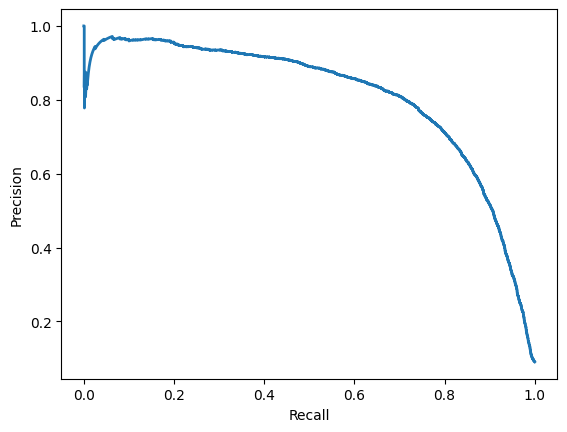

In [34]:
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

Once we decided which precision/recall we're aiming for our project, we can get the lowest threshold that gives that precision/recall with NumPy argmax() method; suppose we aim for a precision of 90%:

In [35]:
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

Now, instead of calling .predict() to make predictions, we run the code as before:

In [36]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

Let's compute precision and recall:

In [37]:
precision_score(y_train_5, y_train_pred_90), recall_score(y_train_5, y_train_pred_90)

(0.9000345901072293, 0.4799852425751706)

We obtained a 90% precision classifier (note that recall is 48%, which is commonly low, so this classifier is not very reliable).

#### ROC (Receiving Operating Characteristic) Curve
The **ROC** is another common tool for **binary classifiers**: it plots the **Recall** (or **TPR**) against the **Fall-Out** (or **FPR**).

The **FPR** is equal to 1- **TNR**; the **TNR** is also called **specificity**, while the **FPR** is also called **sensitivity**.

So the ROC Curve plots the Recall/TPR against the Fall-Out/FPR/1-specificity.

To plot it, we first use *roc_curve()* to compute **TPR** and **FPR** for various threshold values:

In [ ]:
from sklearn.metrics import roc_curve